In [1]:
# Configuration and File Paths
import sys
import time
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

from config import get_config, validate_config, setup_directories, print_config_summary
from src.simulation import simulate_asset_damage_recovery_access_optimized
from src.data_loader import load_hazard_maps, load_electricity_assets
from src.visualization import *
import src.grid_based_accessibility_hex as grid_hex

# #TODO: import and run sensitivity analysis


In [2]:
# Get configuration (currently from config.py)
config = get_config()

# Validate and setup
is_valid, missing_dirs = validate_config(config)
setup_directories(config)

# Print summary
print_config_summary(config)

# Handle validation results
if missing_dirs:
    print(f"\nWarning: Missing directories: {missing_dirs}")
else:
    print("\nAll data directories found successfully!")

# Set the hazard extraction method constant
HAZARD_EXTRACTION_METHOD = config['analysis_config']['hazard_extraction_method']
print(f"Hazard extraction method set to: {HAZARD_EXTRACTION_METHOD}")



Configuration Summary
Root directory: c:\repos\powerpath
Assets data: c:\repos\powerpath\data\electricity
Hazard data: N:\Projects\11209000\11209175\B. Measurements and calculations\Data\timeseries_data\reprojected
Interim directory: c:\repos\powerpath\data\interim\interim_reprojected
Output directory: c:\repos\powerpath\data\output\output_reprojected

Simulation Configuration:
  number_repair_crews: 10
  repair_crew_assignment_method: islands
  flood_threshold: 0.2
  verbose: True

Recovery Parameters:
  repair_time_coefficients: [702.72, 3.14, 1.9891]
  damage_ratio_coefficients: (0.0468, 0.0077)
  time_step_hours: 1
  damage_threshold: 0.01
  repair_threshold: 2.0

Analysis Configuration:
  hazard_extraction_method: max
  max_simulation_days: None
  cache_enabled: True
  performance_monitoring: False

All data directories found successfully!
Hazard extraction method set to: max


In [3]:
# Load data
print("Loading electricity assets...")
gdf_assets = load_electricity_assets(config['electricity_dir'])

print("\nLoading hazard maps...")
hazard_maps = load_hazard_maps(config['hazard_dir'], max_days=10)  
print("Data loading completed!")
print(f"\nHazard maps loaded:")
for i, hm in enumerate(hazard_maps):
    if i < 3:
        print(f"  -{hm}")
    elif i == 3:
        print(f"  and {len(hazard_maps) - 3} more")
        break




Loading electricity assets...
Loading electricity assets from ls_stations_clipped.shp
Loaded 603 ls assets
Loading electricity assets from msls_stations_clipped.shp
Loaded 1258 msls assets
Combined total: 1861 electricity assets
Asset types: {'msls': 1258, 'ls': 603}

Loading hazard maps...
Found 9 hazard map files
Data loading completed!

Hazard maps loaded:
  -N:\Projects\11209000\11209175\B. Measurements and calculations\Data\timeseries_data\reprojected\0_blank_map.tif
  -N:\Projects\11209000\11209175\B. Measurements and calculations\Data\timeseries_data\reprojected\20220610 JF  Limburgbui 200 mm 48h  voormalen 15 cm  GHG_waterschijf_1900-01-03_scale_5_wgs84.tif
  -N:\Projects\11209000\11209175\B. Measurements and calculations\Data\timeseries_data\reprojected\20220610 JF  Limburgbui 200 mm 48h  voormalen 15 cm  GHG_waterschijf_1900-01-04_scale_5_wgs84.tif
  and 6 more


In [4]:
# Configure simulation parameters from config
simulation_params = {
    'flood_threshold': config['simulation_config']['flood_threshold'],
    'number_repair_crews': config['simulation_config']['number_repair_crews'],
    'repair_crew_assignment_method': config['simulation_config']['repair_crew_assignment_method'],
    'verbose': config['simulation_config']['verbose'],
    'damage_ratio_coefficients': config['recovery_parameters']['damage_ratio_coefficients'],
    'repair_time_coefficients': config['recovery_parameters']['repair_time_coefficients'],
    'damage_threshold': config['recovery_parameters']['damage_threshold'],
    'repair_threshold': config['recovery_parameters']['repair_threshold'],
    'config': config  # Pass entire config for directory management
}

accessibility_model = grid_hex.accessibility_model
simulation_params['accessibility_model'] = accessibility_model



print(f"\nSimulation configuration:")
for key, value in simulation_params.items():
    if key != 'config':  # Don't print the entire config
        print(f"  {key}: {value}")

print(f"\nDirectory structure:")
print(f"  Interim: {config['interim_dir']}")
print(f"  Output: {config['output_dir']}")
print(f"  Cache will be organized by hazard directory: {Path(config['hazard_dir']).name}")



Simulation configuration:
  flood_threshold: 0.2
  number_repair_crews: 10
  repair_crew_assignment_method: islands
  verbose: True
  damage_ratio_coefficients: (0.0468, 0.0077)
  repair_time_coefficients: [702.72, 3.14, 1.9891]
  damage_threshold: 0.01
  repair_threshold: 2.0
  accessibility_model: <function accessibility_model at 0x00000241B0150900>

Directory structure:
  Interim: c:\repos\powerpath\data\interim\interim_reprojected
  Output: c:\repos\powerpath\data\output\output_reprojected
  Cache will be organized by hazard directory: reprojected


In [5]:
# simulation_params['verbose'] = False  # Set verbose to False for cleaner output

execution_id = int(time.time())
print(f"***Starting simulation execution {execution_id}***")

# Run the  simulation
results_df, final_state = simulate_asset_damage_recovery_access_optimized(
    gdf_assets=gdf_assets,
    hazard_maps=hazard_maps,
    number_repair_crews=simulation_params['number_repair_crews'],
    repair_crew_assignment_method=simulation_params['repair_crew_assignment_method'],
    flood_threshold=simulation_params['flood_threshold'],
    recovery_parameters=config['recovery_parameters'],
    root_dir=config['root_dir'],
    verbose=simulation_params['verbose']
)

print(f"***Completed simulation execution {execution_id}***")

***Starting simulation execution 1754560216***
Using hazard directory for cache naming: reprojected
Loading optimization caches...
No accessibility cache found at c:\repos\powerpath\data\interim\accessibility_cache_reprojected.pkl
No hazard extraction cache found at c:\repos\powerpath\data\interim\cache\hazard_extraction_cache_reprojected.pkl
Pre-computing island assignments...
Pre-computing island assignments for 9 hazard maps and 3 thresholds...
No island cache found at c:\repos\powerpath\data\interim\cache\island_cache_reprojected.pkl
  Computing [1]: 0_blank_map.tif, threshold 0.1
Loading graph from: c:\repos\powerpath\data\static\output_graph\base_graph_hazard_editted.p
Using hazard_threshold=0.1, hazard_column=EV0_ma
Loaded 20584 island features
After deduplication: 10314 island features
Created 20 dissolved road islands
Successfully assigned 1861 assets to islands
  Computing [2]: 0_blank_map.tif, threshold 0.2
Loading graph from: c:\repos\powerpath\data\static\output_graph\base

100%|██████████| 450/450 [00:06<00:00, 66.01it/s] 


Island-based method 'islands' will be used

=== Processing timestep 0 (day 0) ===
Extracting hazard values using method: max
Cached hazard extraction results for day 0 from 0_blank_map.tif
Using cached islands for 0.2_EV0_ma
Processing 9 islands with crew distribution...
Initial distribution of 10 crews across 9 islands
Computing accessibility for day 0 (hazard dir: reprojected)...
Using project root: c:\repos\powerpath
Running hazard grid analysis for N:\Projects\11209000\11209175\B. Measurements and calculations\Data\timeseries_data\reprojected\0_blank_map.tif with threshold 0.2 m
Running hazard grid analysis for N:\Projects\11209000\11209175\B. Measurements and calculations\Data\timeseries_data\reprojected\0_blank_map.tif with threshold 0.2 m


100%|██████████| 450/450 [00:23<00:00, 19.13it/s]


Grid has 450 cells
Baseline reachable cells: 4.32 (avg)
Hazard reachable cells: 4.33 (avg)
Accessibility updated for timestep 0 (day 0)
Accessible assets: 1765 out of 1861
Day 0 summary: 1861/1861 operational, 1765 accessible, 0 flooded

=== Processing timestep 24 (day 1) ===
Extracting hazard values using method: max
Cached hazard extraction results for day 1 from 20220610 JF  Limburgbui 200 mm 48h  voormalen 15 cm  GHG_waterschijf_1900-01-03_scale_5_wgs84.tif
Using cached islands for 0.2_EV1_ma
Processing 15 islands with crew distribution...
Cached overlaps for overlap_reprojected_0_1_0.2
Redistributed 9 crews from previous island 0 based on cached overlaps
Assigned 1 crews to nearest island 2
  New damage at timestep 24: 24 assets
  Damage ratios: 0.018 to 0.228
  Repair times: 2.3 to 39.4 hours
Computing accessibility for day 1 (hazard dir: reprojected)...
Using project root: c:\repos\powerpath
Running hazard grid analysis for N:\Projects\11209000\11209175\B. Measurements and calcu

...

Grid has 450 cells
Baseline reachable cells: 4.32 (avg)
Hazard reachable cells: 4.47 (avg)
Accessibility updated for timestep 144 (day 6)
Accessible assets: 1795 out of 1861
Assigning repair crews to island 0 with 9 available crews and 19 repairable assets
Assigned 9 repair crews to island 0 based on method 'islands'
Assets [49, 148, 240, 241] became operational at timestep 146
Assigning repair crews to island 0 with 4 available crews and 10 repairable assets
Assigned 4 repair crews to island 0 based on method 'islands'
Assets [922] became operational at timestep 147
Assigning repair crews to island 0 with 1 available crews and 6 repairable assets
Assigned 1 repair crews to island 0 based on method 'islands'
Assets [1043, 1529] became operational at timestep 148
Assigning repair crews to island 0 with 2 available crews and 5 repairable assets
Assigned 2 repair crews to island 0 based on method 'islands'
Assets [338, 374, 927] became operational at timestep 149
Assigned 3 repair crews t

100%|██████████| 450/450 [00:22<00:00, 19.61it/s]


Grid has 450 cells
Baseline reachable cells: 4.32 (avg)
Hazard reachable cells: 4.47 (avg)
Accessibility updated for timestep 168 (day 7)
Accessible assets: 1795 out of 1861
Assets [391] became operational at timestep 182
Assets [389] became operational at timestep 183
Assets [390] became operational at timestep 186
Day 7 summary: 1860/1861 operational, 1795 accessible, 0 flooded

=== Processing timestep 192 (day 8) ===
Extracting hazard values using method: max
Cached hazard extraction results for day 8 from z3_blank_map.tif
Using cached islands for 0.2_EV8_ma
Processing 9 islands with crew distribution...
Cached overlaps for overlap_reprojected_7_8_0.2
Redistributed 9 crews from previous island 0 based on cached overlaps
Redistributed 1 crews from previous island 2 based on cached overlaps
Computing accessibility for day 8 (hazard dir: reprojected)...
Using project root: c:\repos\powerpath
Running hazard grid analysis for N:\Projects\11209000\11209175\B. Measurements and calculations

100%|██████████| 450/450 [00:23<00:00, 19.53it/s]


Grid has 450 cells
Baseline reachable cells: 4.32 (avg)
Hazard reachable cells: 4.47 (avg)
Accessibility updated for timestep 192 (day 8)
Accessible assets: 1795 out of 1861
Day 8 summary: 1860/1861 operational, 1795 accessible, 0 flooded
Saving optimization caches...
Saved accessibility cache: 9 entries to c:\repos\powerpath\data\interim\accessibility_cache_reprojected.pkl
Saved hazard extraction cache: 9 entries to c:\repos\powerpath\data\interim\cache\hazard_extraction_cache_reprojected.pkl
Saved overlap cache: 8 entries to c:\repos\powerpath\data\interim\overlap_cache_reprojected.pkl
Saved updated island cache with 27 entries to c:\repos\powerpath\data\interim\cache\island_cache_reprojected.pkl
***Completed simulation execution 1754560216***


In [6]:
# Print text summary
print_simulation_summary(results_df, gdf_assets, config)

SIMULATION RESULTS SUMMARY
Total assets: 1861
Simulation duration: 216 hours (9 days)
Final operational rate: 99.9%
Peak damaged assets: 46
Peak flooded assets: 46
Total crew assignments: 211

RECOVERY TIMELINE (Daily Summary)
Day 0: 100.0% operational, 0.0 flooded, 0.0 damaged
Day 1: 98.7% operational, 24.0 flooded, 24.0 damaged
Day 2: 97.5% operational, 46.0 flooded, 46.0 damaged
Day 3: 97.7% operational, 36.0 flooded, 42.0 damaged
Day 4: 98.3% operational, 28.0 flooded, 32.0 damaged
Day 5: 98.9% operational, 16.0 flooded, 20.0 damaged
Day 6: 99.8% operational, 0.0 flooded, 4.0 damaged
Day 7: 99.9% operational, 0.0 flooded, 1.0 damaged
Day 8: 99.9% operational, 0.0 flooded, 1.0 damaged

REPAIR BACKLOG ANALYSIS
Hour | Flooded | Damaged | Crews | Backlog | Effective?
-------------------------------------------------------
 0.0 |     0.0 |     0.0 |   0.0 |     0.0 | No
24.0 |    24.0 |    24.0 |   0.0 |   166.2 | No
48.0 |    46.0 |    46.0 |   0.0 |   231.9 | No
72.0 |    36.0 |    46

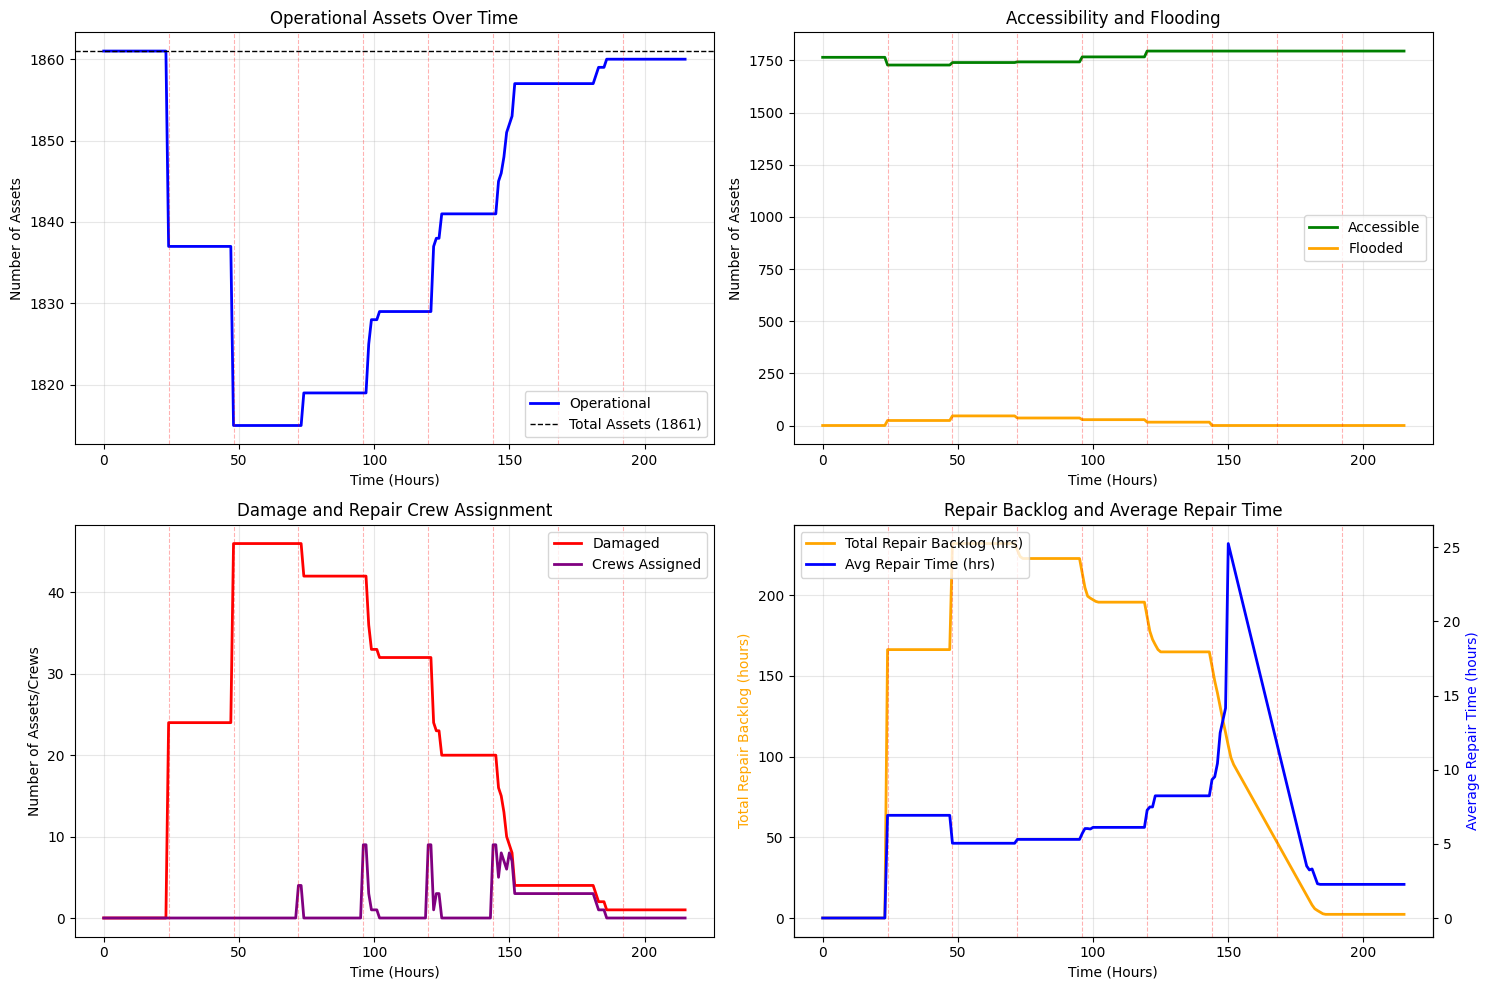

In [7]:
# Show summary plot
fig1 = plot_simulation_results_summary(results_df, gdf_assets, config)
plt.show()

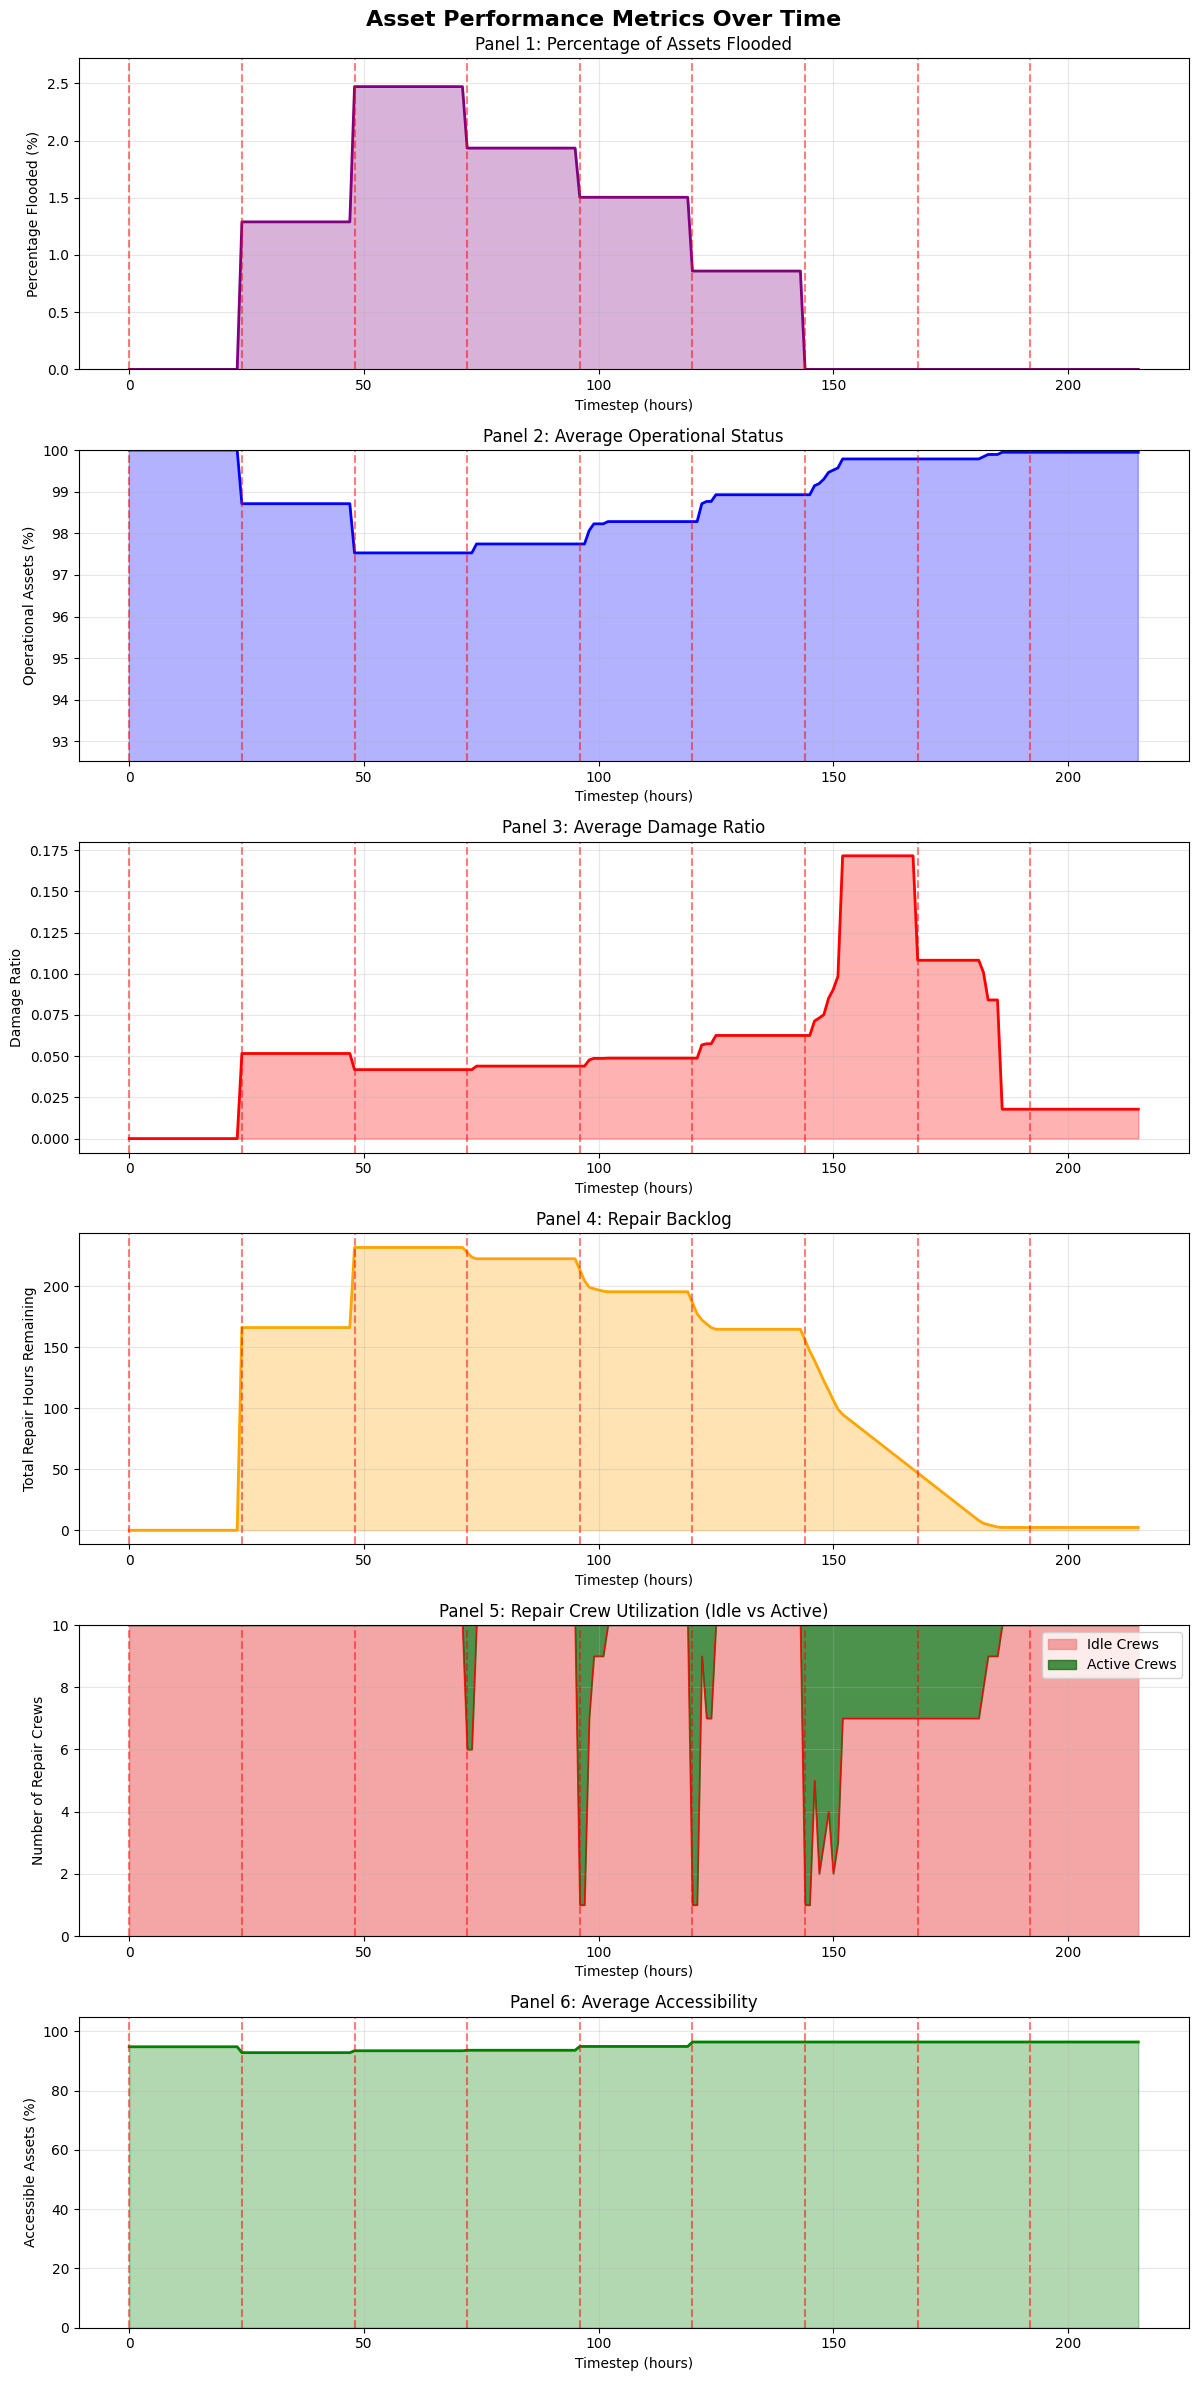

In [8]:
# Show detailed analysis
fig2 = plot_detailed_analysis_panels(results_df, gdf_assets, config)
plt.show()

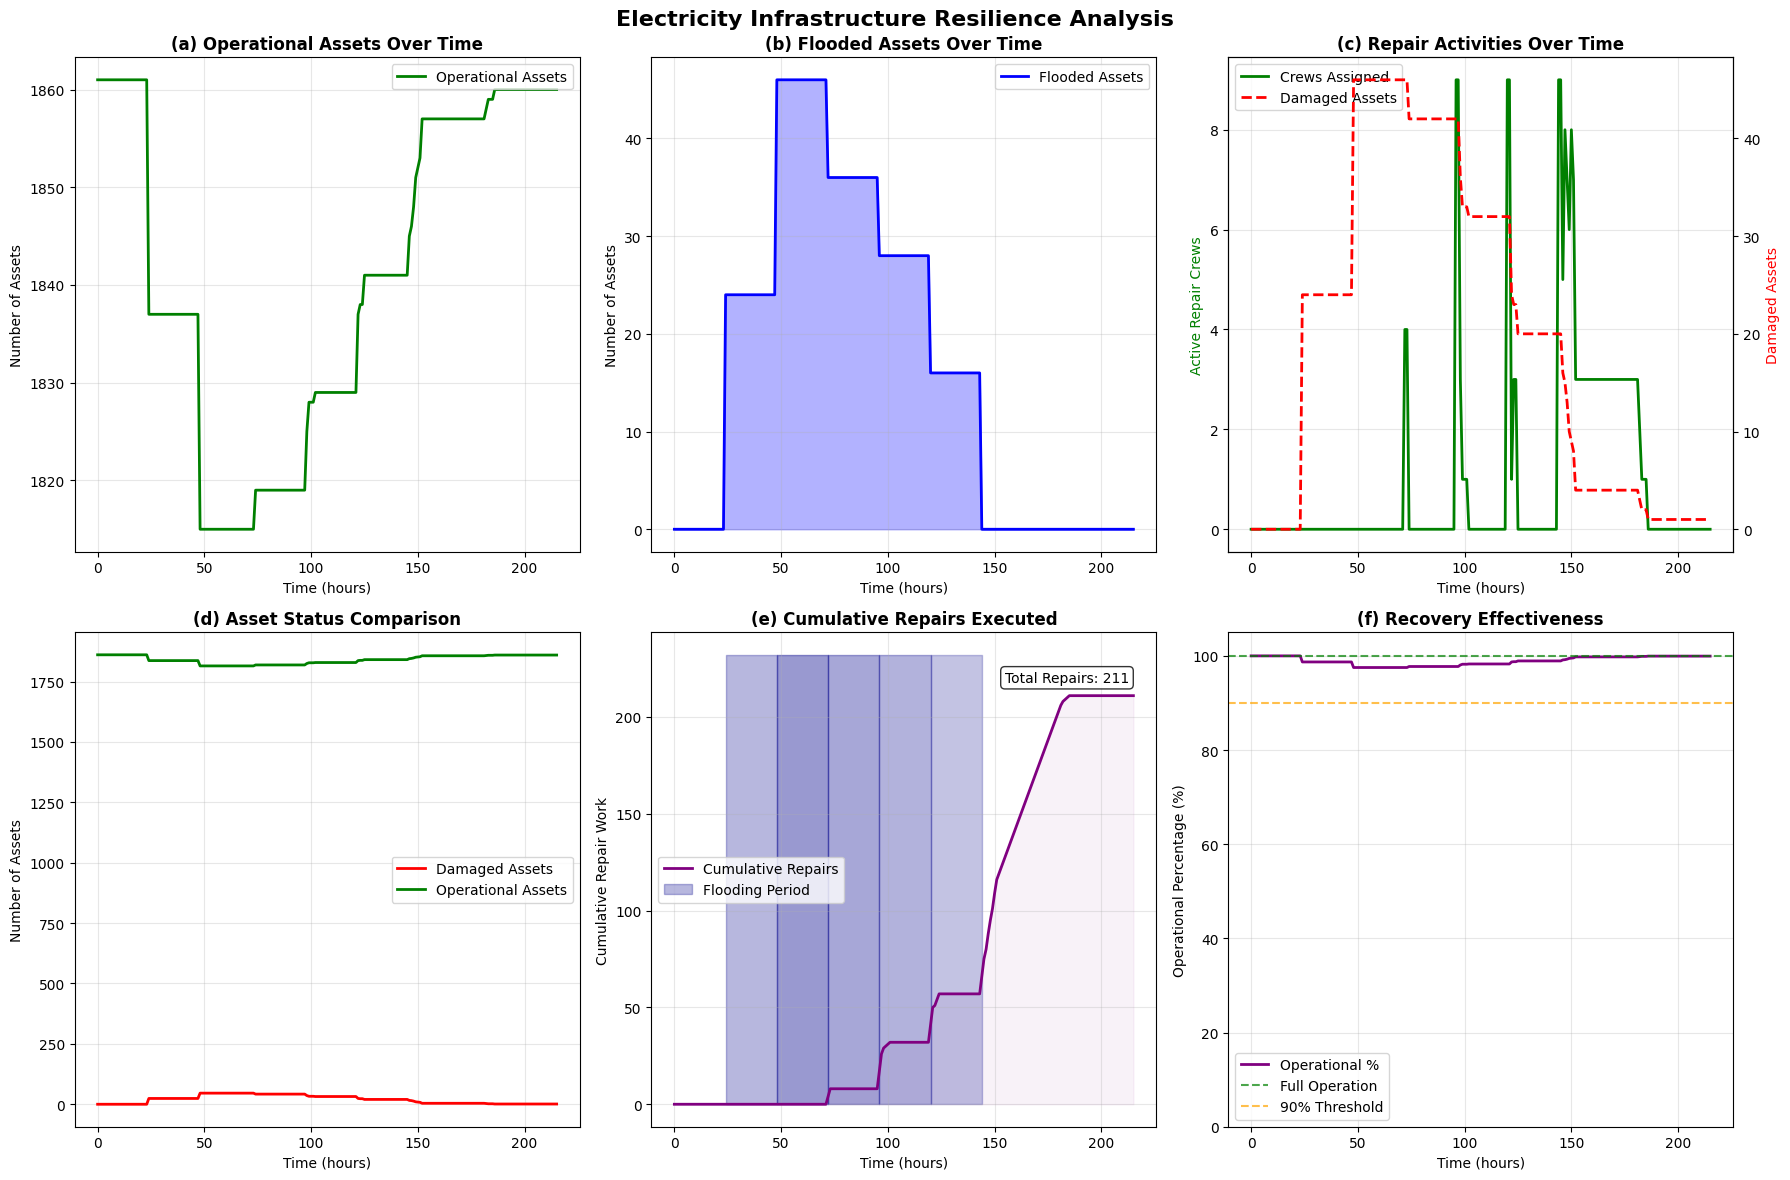

In [9]:
# Show comprehensive visualization
fig3 = create_comprehensive_visualization(results_df, gdf_assets, config)
plt.show()

In [10]:
# Save all visualizations
saved_files = save_all_visualizations(results_df, gdf_assets, config, config['output_dir'])

Saved 4 files to c:\repos\powerpath\data\output\output_reprojected
   Combined PDF: all_visualizations_20250807_121028.pdf
   Individual PNGs: 3 files


In [11]:
from src.simulation import analyze_simulation_performance
# Run the performance analysis - add this as a new cell
print("Running performance analysis...")
performance_data, test_results, simulation_time = analyze_simulation_performance(
    gdf_assets, hazard_maps, config, max_days=3
)

print(f"\nQuick recommendations based on results:")
print(f"  Total simulation time for 3 days: {simulation_time:.1f}s")
print(f"  Estimated time for 10 days: {simulation_time * 10/3:.1f}s")

# Show which functions are consuming the most time
if performance_data['function_calls']:
    total_tracked_time = sum(sum(times) for times in performance_data['function_calls'].values())
    print(f"  Time in tracked functions: {total_tracked_time:.1f}s ({total_tracked_time/simulation_time*100:.1f}% of total)")

Running performance analysis...
Starting performance analysis (max 3 days)
Baseline memory: 719.2 MB
Using hazard directory for cache naming: reprojected
Loading optimization caches...
Loaded accessibility cache: 9 entries from c:\repos\powerpath\data\interim\accessibility_cache_reprojected.pkl
Loaded overlap cache: 8 entries from c:\repos\powerpath\data\interim\overlap_cache_reprojected.pkl
Loaded hazard extraction cache: 9 entries from c:\repos\powerpath\data\interim\cache\hazard_extraction_cache_reprojected.pkl
Pre-computing island assignments...
Pre-computing island assignments for 3 hazard maps and 3 thresholds...
Loaded island cache: 27 entries from c:\repos\powerpath\data\interim\cache\island_cache_reprojected.pkl
Saved island cache: 27 entries to c:\repos\powerpath\data\interim\cache\island_cache_reprojected.pkl
Island assignment pre-computation complete:
  Total combinations: 9
  Newly computed: 0
  Skipped (cached): 9
Initializing grid-based accessibility analysis...
Using ca